In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NPOC"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".5"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
os.environ["NPROC"] = "1"
os.environ["intra_op_parallelism_threads"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from gravpop import *
import h5py
import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

### For saving and loading
### should be in newest gravpop version
_NONE_ATTR = "__is_none__"

def save_dict_h5(filename, data):
    def _save_group(h5group, d):
        for k, v in d.items():
            if v is None:
                g = h5group.create_group(k)
                g.attrs[_NONE_ATTR] = True
            elif isinstance(v, dict):
                _save_group(h5group.create_group(k), v)
            elif isinstance(v, pd.DataFrame):
                g = h5group.create_group(k)
                g.create_dataset("columns", data=np.array(v.columns, dtype="S"))
                g.create_dataset("values", data=v.to_numpy())
            elif isinstance(v, (list, tuple)):
                arr = np.array(v)
                if arr.dtype.kind in {"U", "O"}:  # strings (or objects that are strings)
                    arr = arr.astype("S")
                h5group.create_dataset(k, data=arr)
            elif isinstance(v, str):
                h5group.create_dataset(k, data=np.bytes_(v))  # NumPy 2.0+
            else:
                h5group.create_dataset(k, data=np.array(v))
    with h5py.File(filename, "w") as f:
        _save_group(f, data)

def load_dict_h5(filename):
    def _load_group(h5group):
        out = {}
        for k, v in h5group.items():
            if isinstance(v, h5py.Group):
                # None sentinel?
                if v.attrs.get(_NONE_ATTR, False):
                    out[k] = None
                # DataFrame?
                elif "columns" in v and "values" in v:
                    cols = [c.decode() for c in v["columns"][()]]
                    out[k] = pd.DataFrame(v["values"][()], columns=cols)
                else:
                    out[k] = _load_group(v)
            else:
                arr = v[()]
                if arr.dtype.kind == "S":
                    # Return string arrays as Python lists of str; scalars as str
                    out[k] = arr.decode() if arr.ndim == 0 else [x.decode() for x in arr.flatten()]
                else:
                    out[k] = arr.tolist() if arr.ndim == 0 else arr
        return out
    with h5py.File(filename, "r") as f:
        return _load_group(f)

/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [2]:
event_data = load_dict_h5("/home/asad.hussain/O4b_test/o4a_data_products/event_data.hdf5");
selection_data = load_dict_h5("/home/asad.hussain/O4b_test/o4a_data_products/selection_data.h5");
analysis_time = selection_data.pop('analysis_time')
total_generated = selection_data.pop('total_generated')
total_detected = selection_data.pop('total_detected')
selection_func = SelectionFunction(selection_data, analysis_time=analysis_time, total_generated=total_generated, total_detected=total_detected);

In [3]:
for k, v in selection_data.items():
    if np.any(~np.isfinite(v)):
        print(k)

In [4]:
for k, v in event_data.items():
    if np.any(~np.isfinite(v)):
        print(k)

# Define Models

In [5]:
smoothed_mass_model = SmoothedTwoComponentPrimaryMassRatio(mmin_fixed=2, mmax_fixed=300, gaussian_mass_maximum=100,
                                 var_names=['mass_1_source', 'mass_ratio'],
                                 hyper_var_names=['alpha', 'beta', 'lam', 'mpp', 'sigpp', 'delta_m', 'mmin', 'mmax'])
    

redshift_model = PowerLawRedshift(var_names=['redshift'],hyper_var_names=['lamb'], z_max=3);

"""
the_spin_orientation_model_2D = GaussianIsotropicSpinOrientationsIIDAnalytic2D(
    a=-1, b=1,
    var_names=['cos_tilt_1', 'cos_tilt_2'],
    hyper_var_names=['xi_spin','sigma_spin']
)

the_spin_orientation_model_1D = GaussianIsotropicSpinOrientationsIIDAnalytic(
    a=-1, b=1,
    var_names=['cos_tilt_1', 'cos_tilt_2'],
    hyper_var_names=['xi_spin','sigma_spin']
)
"""

model_tilt1__ = TruncatedGaussian2DAnalytic(a = [-1,-1], b = [1,1],
                                 var_names=['cos_tilt_1', 'cos_tilt_2'],
                                 hyper_var_names=['mu_spin', 'sigma_spin', 'mu_spin', 'sigma_spin', 'rho_cos_tilt'])

model_tilt1 = FixedParameters(model_tilt1__, {'rho_cos_tilt' : 1e-4}) ## Dont do zero because derivatives can be nan


model_tilt_uniform = Uniform2DAnalytic(a=[-1,-1], b=[1,1],
                      var_names=['cos_tilt_1', 'cos_tilt_2'],
                      hyper_var_names=[])

model_tilt = mixture([model_tilt1, model_tilt_uniform], ['xi_spin', 'one_minus_xi_spin'])


chi_model = TruncatedGaussian2DAnalytic(a = [0,0], b = [1,1],
                                 var_names=['chi_1', 'chi_2'],
                                 hyper_var_names=['mu_chi', 'sigma_chi', 'mu_chi', 'sigma_chi', 'rho_chi'])

chi_model = FixedParameters(chi_model, {'rho_chi' : 1e-4})

"""
var_names = ['chi_1', 'chi_2'];
a = [0,0]; b=[1,1];

spin_2D_a = TruncatedGaussian2DAnalytic(
    var_names=var_names,
    hyper_var_names=['mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0', 'rho_chi_1'],
    a=a,
    b=b
)
spin_2D_b = TruncatedGaussian2DAnalytic(
    var_names=var_names,
    hyper_var_names=['mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2', 'rho_chi_2'],
    a=a,
    b=b
)

full_spin_model = mixture(
    [spin_2D_a, spin_2D_b],
    ['eta_spin', 'one_minus_eta_spin']
)
"""

"\nvar_names = ['chi_1', 'chi_2'];\na = [0,0]; b=[1,1];\n\nspin_2D_a = TruncatedGaussian2DAnalytic(\n    var_names=var_names,\n    hyper_var_names=['mu_chi_1_at_0', 'sigma_chi_1_at_0', 'mu_chi_2_at_0', 'sigma_chi_2_at_0', 'rho_chi_1'],\n    a=a,\n    b=b\n)\nspin_2D_b = TruncatedGaussian2DAnalytic(\n    var_names=var_names,\n    hyper_var_names=['mu_chi_1', 'sigma_chi_1', 'mu_chi_2', 'sigma_chi_2', 'rho_chi_2'],\n    a=a,\n    b=b\n)\n\nfull_spin_model = mixture(\n    [spin_2D_a, spin_2D_b],\n    ['eta_spin', 'one_minus_eta_spin']\n)\n"

# Define Priors

In [6]:
mass_redshift_priors = dict(
    alpha 			= dist.Uniform(-4,12),
    lam 			= dist.Uniform(0,1),
    mmin 			= dist.Uniform(2,6),
    mmax 			= DiracDelta(300),
    beta 			= dist.Uniform(-2,7),
    mpp 			= dist.Uniform(20,50),
    sigpp 			= dist.Uniform(1,10),
    delta_m 		= dist.Uniform(0,12),
    lamb 			= dist.Uniform(-10,10)
)

spin_mag_priors = dict(
    mu_chi = dist.Uniform(0.1, 0.9),
    sigma_chi = dist.Uniform(0.1, 1), # NOTE: changed from 0 min bbound
)

spin_orientation_standard_priors = dict(
    mu_spin = dist.Uniform(-1, 1),
    xi_spin 	= dist.Uniform(0,1),
    sigma_spin 	= dist.Uniform(0.2, 1)
)

priors = mass_redshift_priors.copy()
priors.update(spin_mag_priors)
priors.update(spin_orientation_standard_priors)

# Define Likelihood

In [7]:
HL = MarginalizedHybridLikelihood(
    event_data=event_data,
    selection_data=selection_func,
    models=[smoothed_mass_model, redshift_model, model_tilt, chi_model],
    models_selection=[smoothed_mass_model, redshift_model, model_tilt, chi_model],
    fix_kernels_selection={},
    fix_kernels_events={}
)

In [8]:
rkeys = jax.random.split(jax.random.key(1), len(priors))
test = {
    k : v.value if isinstance(v, DiracDelta) else v.sample(rk)
    for ((k, v), rk) in zip(priors.items(), rkeys)
}

In [9]:
test

{'alpha': Array(7.241844, dtype=float32),
 'lam': Array(0.40364635, dtype=float32),
 'mmin': Array(4.2311363, dtype=float32),
 'mmax': 300,
 'beta': Array(4.0600433, dtype=float32),
 'mpp': Array(21.385798, dtype=float32),
 'sigpp': Array(8.135462, dtype=float32),
 'delta_m': Array(9.449367, dtype=float32),
 'lamb': Array(4.02849, dtype=float32),
 'mu_chi': Array(0.58264035, dtype=float32),
 'sigma_chi': Array(0.9750444, dtype=float32),
 'mu_spin': Array(0.46869493, dtype=float32),
 'xi_spin': Array(0.9177871, dtype=float32),
 'sigma_spin': Array(0.7873723, dtype=float32)}

In [10]:
HL.logpdf(test)

Array(-1340.8604, dtype=float32)

# Define Sampler

In [11]:
samp = Sampler(
    priors=priors,
    latex_symbols={k:k for k in priors.keys()},
    likelihood=HL,
    validation=True
);

# Run Sampler

In [12]:
samp.sample()

Validation enabled


  0%|          | 0/3000 [00:00<?, ?it/s]E0211 13:17:00.412170 2060634 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit__body_fn for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0211 13:17:14.274456 2060516 slow_operation_alarm.cc:140] The operation took 2m13.862997931s

********************************
[Compiling module jit__body_fn for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
sample: 100%|██████████| 3000/3000 [14:58<00:00,  3.34it/s, 15 steps of size 2.84e-01. acc. prob=0.89] 



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      3.78      0.24      3.78      3.39      4.16   1438.64      1.00
        beta      0.91      0.80      0.82     -0.34      2.15   1623.66      1.00
     delta_m      4.97      1.33      4.83      3.00      7.14    920.85      1.00
         lam      0.02      0.01      0.02      0.01      0.04   1260.75      1.00
        lamb      4.69      0.59      4.70      3.73      5.66   2018.96      1.00
        mmin      5.20      0.54      5.30      4.44      5.96    748.29      1.00
         mpp     33.04      1.74     33.32     30.60     35.59    626.00      1.00
      mu_chi      0.16      0.05      0.14      0.10      0.22   1206.97      1.00
     mu_spin      0.13      0.05      0.13      0.05      0.22   1638.64      1.00
   sigma_chi      0.26      0.05      0.26      0.17      0.34   1438.54      1.00
  sigma_spin      0.32      0.09      0.31      0.20      0.43   1668.91      1.00
   

In [13]:
samp.samples.to_csv("result_o4a_old_mass_model.csv")

In [15]:
from util import plot_corner

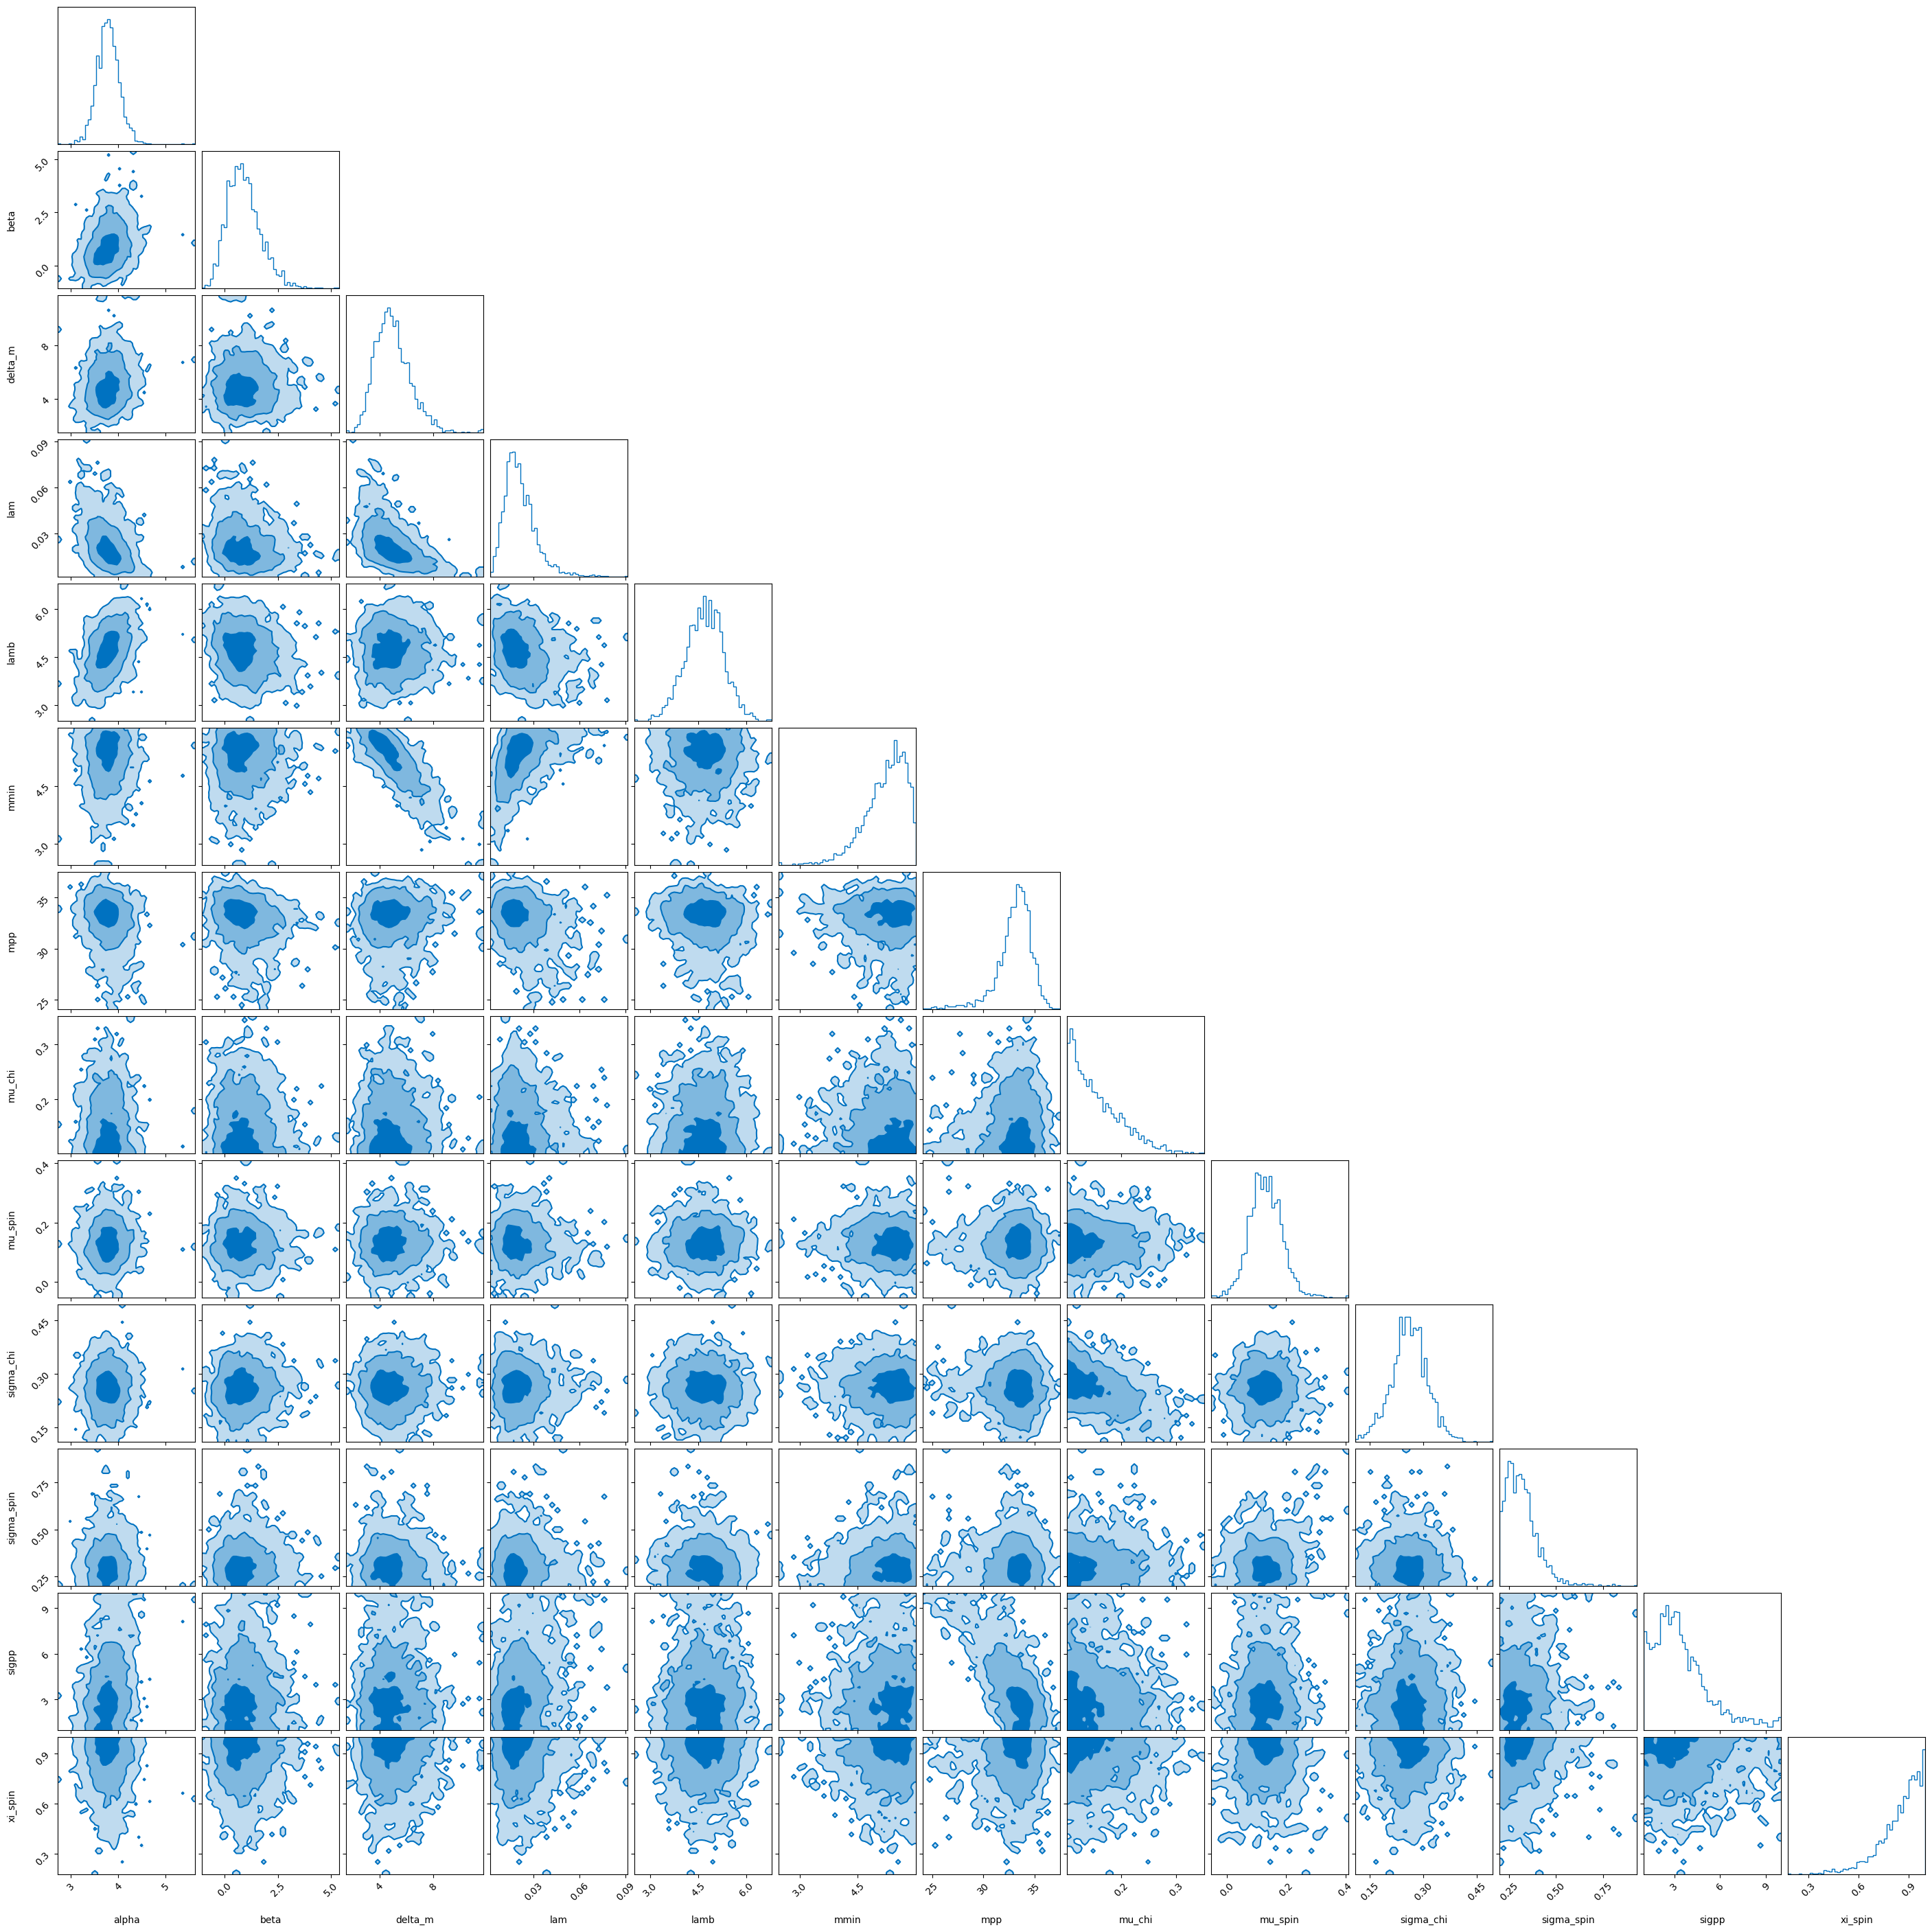

In [16]:
fig = plot_corner(
    samp.samples
)

In [14]:
samp.samples

,alpha,beta,delta_m,lam,lamb,mmin,mpp,mu_chi,mu_spin,sigma_chi,sigma_spin,sigpp,xi_spin
0,3.877736,1.641389,4.550164,0.012785,5.001188,5.860690,32.946407,0.100809,0.145396,0.305395,0.282422,1.586742,0.925053
1,3.483172,0.613257,3.807355,0.029155,4.027196,5.547666,34.518585,0.104756,0.089030,0.278379,0.325724,3.872942,0.808172
2,3.669238,0.817213,6.530788,0.013280,3.815316,4.459099,31.608047,0.160962,0.175202,0.252736,0.281460,2.039272,0.858964
3,3.736341,-0.157754,4.827896,0.018866,5.050653,5.651282,33.843651,0.135947,0.117426,0.281963,0.256726,2.507777,0.995268
4,3.913649,0.951341,3.495841,0.022623,4.825598,5.683484,35.111057,0.127820,0.118480,0.214455,0.235467,2.239427,0.997048
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3.804302,0.250230,4.478877,0.024255,4.827713,5.625901,35.230030,0.138062,0.098448,0.299092,0.203821,1.062570,0.765037
1996,3.544896,0.129534,3.801495,0.021312,4.745478,5.592477,33.071991,0.150836,0.133802,0.202210,0.213310,1.274627,0.833193
1997,3.978674,1.297233,4.514941,0.026276,3.497185,5.128295,33.926971,0.171389,0.057321,0.187694,0.355140,6.425289,0.747259
1998,3.788458,2.865143,3.133953,0.015726,5.116169,5.340731,32.254284,0.178333,0.148139,0.162773,0.256319,1.757606,0.911170
